# Notebook 02 — SimpleMLP 784→40→20→10 on MNIST Digit Classification

**Architecture-specific analyses in §2:** pixel receptive fields, NMF stability.

**Full ablation suite in §3:** comparative sweep, causal circuit ablation, gradient attribution, cross-class circuit specificity.

**Stimulus analysis in §4:** NNLS round-trip, ID sanity check, near-OOD (Fashion-MNIST), far-OOD (4 synthetic types).

## §0 — Imports & Config

In [ ]:
%matplotlib inline
import sys, os, pickle, warnings
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics.pairwise import paired_cosine_distances
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset

from src import (
    SimpleMLP,
    train_epoch, evaluate,
    load_experiment, save_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs, collect_layer_inputs_generic,
    bft,
    bft_node_vals, build_scaffold_edges, scaffold_loading_from_edges,
    scaffold_layer_sizes_from_edges,
    plot_scaffold_graph,
    extract_tree_nodes, compute_node_activations, plot_factor_tree,
    extract_factor_fingerprint, extract_fingerprint_matrix,
    compute_stimulus_similarity, project_stimuli_onto_tree,
    extract_factor_tree_nodes, compute_factor_activations,
    nodes_at_layer, top_stimuli_factor_activations,
    select_class_circuit, magnitude_scores, per_class_accuracy, run_ablation_sweep,
    plot_factor_overview_panel, plot_factor_gallery, plot_input_layer_factors,
    plot_pruning_results, plot_embedding_comparison,
    compute_nmf_stability, plot_nmf_stability_figure,
    compute_k_sensitivity, plot_k_sensitivity_figure,
    plot_robustness_summary,
)
from src.training import label_transform_even_odd

plt.rcParams.update({'figure.dpi': 80})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_ROOT = '../data/models'
CACHE_ROOT = '../data/cache/nb02_mlp4020'
FIG_DIR    = '../figs/02_mlp_40_20_digits'
os.makedirs(MODEL_ROOT, exist_ok=True)
os.makedirs(CACHE_ROOT, exist_ok=True)
os.makedirs(FIG_DIR,    exist_ok=True)

SEED_DIRS = [os.path.join(MODEL_ROOT, f'mnist_digit_mlp_40_20_seed{s}') for s in range(5)]
N_SEEDS   = len(SEED_DIRS)

# ── Model & training config ───────────────────────────────────────────────────
BASE_CONFIG = {
    'arch': 'SimpleMLP',
    'arch_kwargs': {'input_dim': 784, 'hidden_dims': [40, 20], 'output_dim': 10},
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 64},
    'label_transform': 'identity',
    'analysis_layer_indices': [2, 4, 6],
    'n_per_class': 1000,
    'input_side': 28,
}

# ── BFT hyperparameters ───────────────────────────────────────────────────────
K_MAX           = [10, 6, 10]
N_BRANCHES      = [1, 2, 5]
STIM_THRESHOLD  = 0.1
N_CLASSES       = 10
CLASS_NAMES     = {i: str(i) for i in range(N_CLASSES)}
IMAGE_SIDE      = 28

# ── Ablation hyperparameters ──────────────────────────────────────────────────
METHODS = ['bft_top', 'bft_bottom', 'magnitude', 'random']
METHOD_COLORS = {
    'bft_top':    '#e15759',
    'bft_bottom': '#f28e2b',
    'magnitude':  '#76b7b2',
    'random':     '#333333',
}
METHOD_LABELS = {
    'bft_top':    'BFT most important',
    'bft_bottom': 'BFT least important',
    'magnitude':  'Magnitude',
    'random':     'Random',
}
ABLATION_FRACS   = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_RANDOM_REPEATS = 10
K_TRACE          = K_MAX

# ── NNLS analysis ─────────────────────────────────────────────────────────────
N_PER_CLASS_BFT  = 1000
TOP_N_FACTOR     = 50

# ── Caching ───────────────────────────────────────────────────────────────────
USE_CACHED_BFT = True
USE_CACHED_ABL = True

print('Config ready')
print(f'SEED_DIRS: {SEED_DIRS}')

## §1 — Models (5 seeds)

In [3]:
# Build shared train/test loaders from config
from src.checkpoint import MODEL_REGISTRY
_sample_cfg = dict(BASE_CONFIG)
_train_loader, _test_loader = get_loaders_from_config(_sample_cfg)
label_transform = get_transform(BASE_CONFIG['label_transform'])  # None for 'identity'

models = []
for s, seed_dir in enumerate(SEED_DIRS):
    if os.path.isdir(seed_dir) and os.path.exists(os.path.join(seed_dir, 'weights.pt')):
        m, cfg = load_experiment(seed_dir, device=DEVICE)
        m.eval()
        _, acc = evaluate(m, _test_loader, nn.CrossEntropyLoss(),
                          label_transform=label_transform, device=DEVICE)
        print(f'[seed {s}] loaded — test acc = {acc:.4f}')
    else:
        print(f'[seed {s}] not found, training …')
        torch.manual_seed(s)
        m = SimpleMLP(**BASE_CONFIG['arch_kwargs'])
        m.to(DEVICE)
        opt = torch.optim.Adam(m.parameters(), lr=3e-3)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)
        criterion = nn.CrossEntropyLoss()
        for epoch in range(30):
            train_epoch(m, _train_loader, opt, criterion,
                        label_transform=label_transform, device=DEVICE)
            sched.step()
        _, acc = evaluate(m, _test_loader, criterion,
                          label_transform=label_transform, device=DEVICE)
        cfg = dict(BASE_CONFIG)
        cfg['description'] = f'SimpleMLP 784->40->20->10 on MNIST digit classification, seed {s}'
        save_experiment(m, cfg, seed_dir)
        print(f'[seed {s}] trained — test acc = {acc:.4f}')
    models.append(m)

print('\nAll 5 seeds ready.')

[seed 0] not found, training …


[seed 0] trained — test acc = 0.9652
[seed 1] not found, training …
[seed 1] trained — test acc = 0.9651
[seed 2] not found, training …
[seed 2] trained — test acc = 0.9645
[seed 3] not found, training …
[seed 3] trained — test acc = 0.9678
[seed 4] not found, training …
[seed 4] trained — test acc = 0.9619

All 5 seeds ready.


## §2 — Factorization & Inspection (seed 0)

In [4]:
model0, cfg0 = load_experiment(SEED_DIRS[0], device=DEVICE)
model0.eval()

_p = os.path.join(CACHE_ROOT, 'layer_inputs_seed0.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        _d0 = pickle.load(f)
    print('Loaded layer inputs from cache')
else:
    _d0 = collect_layer_inputs(
        model0, _test_loader.dataset,
        label_transform=label_transform,
        n_per_class=N_PER_CLASS_BFT, device=DEVICE,
    )
    with open(_p, 'wb') as f:
        pickle.dump(_d0, f)
    print('Collected and cached')

layer_inputs0 = _d0['layer_inputs']
all_targets0  = _d0['targets']
all_images0   = _d0['images']
n_samples0    = len(all_targets0)
layer_names   = {0: 'L0 (784→40)', 1: 'L1 (40→20)', 2: 'Out (20→10)'}
print(f'{n_samples0} samples | layers: {[x.shape for x in layer_inputs0]}')

Collected and cached
9446 samples | layers: [(9446, 784), (9446, 40), (9446, 20)]


In [5]:
# ── BFT (seed 0) ──────────────────────────────────────────────────────────────
tree_root0 = bft(
    model0, layer_inputs0,
    k_max=K_MAX, n_branches=N_BRANCHES,
    stimulus_threshold=STIM_THRESHOLD,
    weighting='img_selectivity', verbose=1, n_jobs=3,
)


tree_nodes0   = extract_tree_nodes(tree_root0)
factor_nodes0 = extract_factor_tree_nodes(tree_root0)
l0_nodes0     = nodes_at_layer(tree_root0, 0)
print(f'Tree nodes: {len(tree_nodes0)}  factor nodes: {len(factor_nodes0)}')
print(f'Root factors: K={len(tree_root0["lambdas"])}')

[BFT] Layer 3/3 '2' (fc)  path=[]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L3 '2' (fc)]   K=10  t=395.162s
[BFT] Layer 2/3 '1' (fc)  path=[0]
[BFT L2 '1' (fc)]   K=6  t=5.019s
[BFT] Layer 1/3 '0' (fc)  path=[0, 0]
[BFT L1 '0' (fc)]   K=10  t=23.678s
[BFT] Layer 1/3 '0' (fc)  path=[0, 1]
[BFT L1 '0' (fc)]   K=10  t=21.290s
[BFT] Layer 2/3 '1' (fc)  path=[1]
[BFT L2 '1' (fc)]   K=6  t=6.955s
[BFT] Layer 1/3 '0' (fc)  path=[1, 0]
[BFT L1 '0' (fc)]   K=10  t=26.790s
[BFT] Layer 1/3 '0' (fc)  path=[1, 1]
[BFT L1 '0' (fc)]   K=10  t=23.366s
[BFT] Layer 2/3 '1' (fc)  path=[2]
[BFT L2 '1' (fc)]   K=6  t=2.593s
[BFT] Layer 1/3 '0' (fc)  path=[2, 0]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 '0' (fc)]   K=10  t=796.076s
[BFT] Layer 1/3 '0' (fc)  path=[2, 1]
[BFT L1 '0' (fc)]   K=10  t=21.901s
[BFT] Layer 2/3 '1' (fc)  path=[3]
[BFT L2 '1' (fc)]   K=6  t=2.595s
[BFT] Layer 1/3 '0' (fc)  path=[3, 0]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 '0' (fc)]   K=10  t=986.958s
[BFT] Layer 1/3 '0' (fc)  path=[3, 1]
[BFT L1 '0' (fc)]   K=10  t=21.699s
[BFT] Layer 2/3 '1' (fc)  path=[4]
[BFT L2 '1' (fc)]   K=6  t=4.905s
[BFT] Layer 1/3 '0' (fc)  path=[4, 0]
[BFT L1 '0' (fc)]   K=10  t=27.950s
[BFT] Layer 1/3 '0' (fc)  path=[4, 1]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 '0' (fc)]   K=10  t=1008.555s
Tree nodes: 16  factor nodes: 140
Root factors: K=10


In [ ]:
# ── Plot 1: Factor overview panels ────────────────────────────────────────────
# One figure per factor per BFT tree node: lambda bar, neural heatmap,
# stimulus weight histogram (tab10 per digit class), weighted avg image, top-5 stimuli.
tree_nodes0 = extract_tree_nodes(tree_root0)
os.makedirs(FIG_DIR, exist_ok=True)

for r in tree_nodes0:
    path_label = 'F' + '→F'.join(str(f) for f in r['path']) if r['path'] else 'root'
    figs = plot_factor_overview_panel(r, all_images0, all_targets0, CLASS_NAMES)
    for k, fig in enumerate(figs):
        fname = f"L{r['layer_idx']+1}_{path_label.replace('→','-')}_factor{k}.pdf"
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show(); plt.close(fig)

# ── Plot 4: Per-factor image gallery ──────────────────────────────────────────
# 2 rows: top-10 most active / bottom-10 least active images per factor per node
for r in tree_nodes0:
    path_label = 'F' + '→F'.join(str(f) for f in r['path']) if r['path'] else 'root'
    for k in range(r['img_factors'].shape[1]):
        fig = plot_factor_gallery(r, all_images0, all_targets0, CLASS_NAMES, k=k, n=10)
        fname = f"gallery_L{r['layer_idx']+1}_{path_label.replace('→','-')}_k{k}.pdf"
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show(); plt.close(fig)

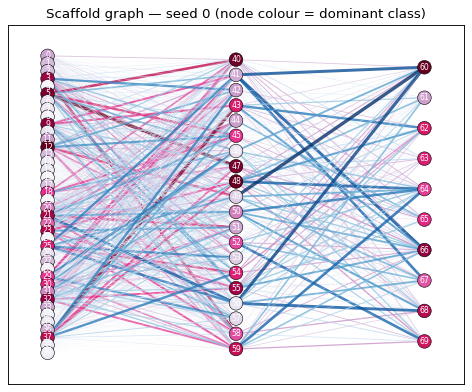

In [7]:
# ── Scaffold graph (seed 0) ───────────────────────────────────────────────────
def _get_spine(root):
    chain, node = [root], root
    while node['children']:
        node = node['children'][0]; chain.append(node)
    return chain

spine = _get_spine(tree_root0)
layer_results = list(reversed(spine))          # forward order: input → output
edge_matrices, neg_edge_matrices = build_scaffold_edges(
    layer_results[1:], fi='path', fi_seed=layer_results[0], top_pct=0.05,
)
scaffold_loading = scaffold_loading_from_edges(edge_matrices)
layer_sizes = scaffold_layer_sizes_from_edges(edge_matrices)
fig = plot_scaffold_graph(scaffold_loading, edge_matrices, layer_sizes,
                          neg_edge_matrices=neg_edge_matrices)
fig.axes[0].set_title('Scaffold graph — seed 0 (node colour = dominant class)', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'scaffold_seed0.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Plot 2: Input-layer pixel receptive fields ────────────────────────────────
# Shows neural_factors[:, k] for each L0 leaf node reshaped to (n_out, 28, 28)
l0_nodes0 = nodes_at_layer(tree_root0, 0)
factor_nodes0 = extract_factor_tree_nodes(tree_root0)

for r in l0_nodes0:
    path_label = 'F' + '→F'.join(str(f) for f in r['path']) if r['path'] else 'root'
    figs = plot_input_layer_factors(r, all_images0, arch='fc',
                                    image_shape=(IMAGE_SIDE, IMAGE_SIDE))
    for k, fig in enumerate(figs):
        fname = f"pixel_rf_L{r['layer_idx']+1}_{path_label.replace('→','-')}_k{k}.pdf"
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show(); plt.close(fig)

In [ ]:
# ── Plot 5: Robustness Analysis ────────────────────────────────────────────────

# 5a — NMF initialisation robustness
_rob_cache = os.path.join(CACHE_ROOT, 'nmf_stability.pkl')
if USE_CACHED_BFT and os.path.exists(_rob_cache):
    with open(_rob_cache, 'rb') as f:
        stability_results = pickle.load(f)
    print('Loaded NMF stability from cache')
else:
    stability_results = {}
    for r in tree_nodes0:
        if 'joint_arbor' not in r or r.get('joint_arbor') is None:
            continue
        X = r['joint_arbor']
        if X.shape[0] < 10:
            continue
        k     = r['img_factors'].shape[1]
        key   = (r['layer_idx'], str(r.get('path', [])))
        lname = r.get('layer_name', f"L{r['layer_idx']}")
        print(f"  {lname} k={k} X={X.shape} … ", end='', flush=True)
        sim_mat, _ = compute_nmf_stability(X, k=k, n_seeds=10)
        stability_results[key] = (sim_mat, k, lname)
        print('done')
    with open(_rob_cache, 'wb') as f:
        pickle.dump(stability_results, f)

for key, (sim_mat, k, lname) in stability_results.items():
    fig = plot_nmf_stability_figure(sim_mat,
                                    title=f'{lname}  K={k}  NMF initialisation stability')
    fig.savefig(os.path.join(FIG_DIR,
                             f'robustness_nmf_stability_{lname.replace("/","_")}.pdf'),
                bbox_inches='tight')
    plt.show(); plt.close(fig)

# 5b — Model-seed robustness (compare root img_factors across 5 seeds)
print('\nModel-seed robustness at root node...')
from src.robustness_utils import align_factors as _align_factors

_seed_root_factors = []
for s_idx in range(N_SEEDS):
    _cache_s = os.path.join(CACHE_ROOT, f'bft_seed{s_idx}_rob.pkl')
    m_s, _ = load_experiment(SEED_DIRS[s_idx], device=DEVICE)
    if USE_CACHED_BFT and os.path.exists(_cache_s):
        with open(_cache_s, 'rb') as f:
            _r = pickle.load(f)
    else:
        _ld = collect_layer_inputs(m_s, _test_loader.dataset,
                                   label_transform=label_transform,
                                   n_per_class=None, device=DEVICE)
        _r = bft(m_s, _ld['layer_inputs'], k_max=K_TRACE,
                 n_branches=[1, 1, N_CLASSES],
                 stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
        with open(_cache_s, 'wb') as f:
            pickle.dump(_r, f)
    H = _r['img_factors']
    norms = np.linalg.norm(H, axis=0, keepdims=True)
    _seed_root_factors.append(H / (norms + 1e-12))

ref = _seed_root_factors[0]
_, sim_scores = _align_factors(ref, _seed_root_factors[1:])
print(f'Root factor alignment across seeds: '
      f'{np.array(sim_scores).mean():.3f} ± {np.array(sim_scores).std():.3f}')

# 5c — K sensitivity at root node
print('\nK sensitivity at root...')
if 'joint_arbor' in tree_root0 and tree_root0['joint_arbor'] is not None:
    k_star = tree_root0['img_factors'].shape[1]
    sensitivity, _ = compute_k_sensitivity(tree_root0['joint_arbor'],
                                           k_star=k_star, n_seeds=5)
    fig = plot_k_sensitivity_figure(sensitivity, k_star=k_star,
                                    title=f'Root node K sensitivity (K*={k_star})')
    fig.savefig(os.path.join(FIG_DIR, 'robustness_k_sensitivity_root.pdf'),
                bbox_inches='tight')
    plt.show(); plt.close(fig)

# Summary boxplot
if stability_results:
    sims   = [v[0] for v in stability_results.values()]
    ks     = [v[1] for v in stability_results.values()]
    lnames = [v[2] for v in stability_results.values()]
    fig = plot_robustness_summary(sims, ks, lnames,
                                  title='NMF stability across all BFT nodes')
    fig.savefig(os.path.join(FIG_DIR, 'robustness_summary.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)

In [ ]:
# ── Plot 6: Ablation sweep (all 5 seeds) ──────────────────────────────────────
os.makedirs(os.path.join(CACHE_ROOT, 'ablation'), exist_ok=True)
all_results = []

for s, seed_dir in enumerate(SEED_DIRS):
    cache_path = os.path.join(CACHE_ROOT, 'ablation', f'seed{s}_v2.pkl')
    if USE_CACHED_ABL and os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            all_results.append(pickle.load(f))
        print(f'[seed {s}] loaded from cache')
        continue

    print(f'\n=== seed {s} ===')
    model_s, cfg_s = load_experiment(seed_dir, device=DEVICE)
    model_s.eval()
    _, test_loader_s = get_loaders_from_config(cfg_s)

    data_s = collect_layer_inputs(
        model_s, test_loader_s.dataset,
        label_transform=label_transform, n_per_class=None, device=DEVICE,
    )
    li_s  = data_s['layer_inputs']
    tgt_s = data_s['targets']

    root_s   = bft(model_s, li_s, k_max=K_TRACE, n_branches=[1, 1, N_CLASSES],
                   stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
    mag_sc   = magnitude_scores(model_s)
    baseline = per_class_accuracy(model_s, test_loader_s, label_transform, DEVICE)

    seed_results = {'baseline': baseline}
    for d in range(N_CLASSES):
        bft_sc, info = select_class_circuit(root_s, tgt_s, d)
        if info['warning']:
            print(f'  class {d}: {info["warning"]}')
        else:
            print(f'  class {d}: k*={info["k_star"]} selectivity={info["selectivity"]:.2f}')

        score_map = {
            'bft_top':    bft_sc,
            'bft_bottom': bft_sc,
            'magnitude':  mag_sc,
            'random':     mag_sc,
        }
        seed_results[d] = {}
        for method in METHODS:
            _m = ('algo_top'    if method == 'bft_top'    else
                  'algo_bottom' if method == 'bft_bottom' else method)
            seed_results[d][method] = run_ablation_sweep(
                model_s, score_map[method], ABLATION_FRACS,
                test_loader_s, label_transform, DEVICE,
                method=_m, n_random_repeats=N_RANDOM_REPEATS,
            )

    with open(cache_path, 'wb') as f:
        pickle.dump(seed_results, f)
    all_results.append(seed_results)

valid = [r for r in all_results if r is not None]
print(f'\nValid seeds: {len(valid)}')

In [ ]:
# ── Plot 6 results: pruning curves ────────────────────────────────────────────
baseline_means = {d: float(np.mean([r['baseline'][d] for r in valid])) for d in range(N_CLASSES)}
baseline_stds  = {d: float(np.std( [r['baseline'][d] for r in valid])) for d in range(N_CLASSES)}

pruning_data = {d: {m: {} for m in METHODS} for d in range(N_CLASSES)}
pruning_stds = {d: {m: {} for m in METHODS} for d in range(N_CLASSES)}

for d in range(N_CLASSES):
    for method in METHODS:
        pruning_data[d][method][0.0] = {c: baseline_means[c] for c in range(N_CLASSES)}
        pruning_stds[d][method][0.0] = {c: baseline_stds[c]  for c in range(N_CLASSES)}
        for f in ABLATION_FRACS:
            accs_by_seed = [r[d][method][f] for r in valid]
            pruning_data[d][method][f] = {
                c: float(np.mean([a[c] for a in accs_by_seed])) for c in range(N_CLASSES)
            }
            pruning_stds[d][method][f] = {
                c: float(np.std([a[c] for a in accs_by_seed])) for c in range(N_CLASSES)
            }

fracs_all = [0.0] + ABLATION_FRACS

figs = plot_pruning_results(
    pruning_data, CLASS_NAMES, METHODS, fracs_all,
    method_colors=METHOD_COLORS, method_labels=METHOD_LABELS,
    pruning_stds=pruning_stds,
)
for d, fig in enumerate(figs):
    fig.savefig(os.path.join(FIG_DIR, f'pruning_class{d}_{CLASS_NAMES[d]}.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)

## §4 — New Stimuli via NNLS

In [ ]:
# ── Round-trip test (NNLS projection fidelity) ────────────────────────────────
N_RT = min(200, n_samples0)
rng_rt = np.random.default_rng(0)
rt_sub = rng_rt.choice(n_samples0, N_RT, replace=False)
rt_inputs = [l[rt_sub] for l in layer_inputs0]

projected_rt = project_stimuli_onto_tree(tree_root0, rt_inputs)
F_orig_rt    = extract_fingerprint_matrix(tree_root0, rt_sub)
F_rt         = extract_fingerprint_matrix(projected_rt, np.arange(N_RT))
rt_sims      = 1.0 - paired_cosine_distances(F_orig_rt, F_rt)
rt_root      = 1.0 - paired_cosine_distances(
    tree_root0['img_factors'][rt_sub],
    projected_rt['img_factors'],
)
print(f'Round-trip (full):   mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}  min={rt_sims.min():.4f}')
print(f'Round-trip (root):   mean={rt_root.mean():.4f}  std={rt_root.std():.4f}')
print()
print('Active-sample fraction per node (sw > 0.01):')
for tn in tree_nodes0:
    sw = tn.get('stimulus_weights_in', np.array([1]))
    print(f'  layer={tn["layer_idx"]}  path={tn["path"]}  active={(sw > 0.01).mean():.3f}')

In [ ]:
# ── Near-OOD: Fashion-MNIST ────────────────────────────────────────────────────
FMNIST_CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

_p_ood = os.path.join(CACHE_ROOT, 'near_ood_fmnist.pkl')
if os.path.exists(_p_ood):
    with open(_p_ood, 'rb') as f:
        _d_ood = pickle.load(f)
    print('Loaded near-OOD cache')
else:
    fmnist_test = datasets.FashionMNIST('../data/', train=False, download=True,
                                         transform=ToTensor())
    _d_ood = collect_layer_inputs_generic(
        model0, fmnist_test,
        only_correct=False, label_transform=None, device=DEVICE,
    )
    with open(_p_ood, 'wb') as f:
        pickle.dump(_d_ood, f)
    print('Collected and cached near-OOD')

ood_images  = _d_ood['images']
ood_targets = _d_ood['targets']
ood_inputs  = _d_ood['layer_inputs']
n_ood       = len(ood_images)
print(f'Near-OOD (Fashion-MNIST) samples: {n_ood}')

projected_ood    = project_stimuli_onto_tree(tree_root0, ood_inputs)
factor_nodes_ood = extract_factor_tree_nodes(projected_ood)

# ── Factor tree per Fashion-MNIST class ───────────────────────────────────────
ncols = 5; nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
for i, cl in enumerate(range(10)):
    ax   = axes[i // ncols][i % ncols]
    idx  = np.where(ood_targets == cl)[0]
    acts = compute_factor_activations(factor_nodes_ood, idx)
    plot_factor_tree(factor_nodes_ood, acts, ax=ax,
                     title=f'{FMNIST_CLASSES[cl]}  n={len(idx)}')
plt.suptitle('Near-OOD (Fashion-MNIST) — factor tree per class', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'near_ood_tree_per_class.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Far-OOD: synthetic images ──────────────────────────────────────────────────
N_FAR_OOD = 500
rng_f = np.random.default_rng(99)
_chk  = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(0) % 2).astype(np.float32)

far_ood_arrays = {
    'gaussian_noise': np.clip(
        rng_f.normal(0.5, 0.25, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32),
        0, 1),
    'uniform_gray':   np.full((N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(
        _chk, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  np.clip(1.0 - all_images0[:N_FAR_OOD], 0, 1).astype(np.float32),
}

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    ds = TensorDataset(torch.from_numpy(imgs), torch.zeros(len(imgs), dtype=torch.long))
    d  = collect_layer_inputs_generic(
        model0, ds, only_correct=False, label_transform=None, device=DEVICE,
    )
    d['projected_root'] = project_stimuli_onto_tree(tree_root0, d['layer_inputs'])
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name]  = d
    print(f'{name:20s}  model acc={(d["preds"] == d["targets"]).mean():.3f}')

# ── Factor tree per far-OOD type ──────────────────────────────────────────────
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5), squeeze=False)
for ax, (name, d) in zip(axes[0], far_ood_data.items()):
    acts = compute_factor_activations(d['factor_nodes'], np.arange(len(d['images'])))
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)
plt.suptitle('Far-OOD — factor tree per synthetic type', y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_factor_tree.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Cross-similarity: ID digits vs Fashion-MNIST ──────────────────────────────
N_BLOCK = 30; rng_blk = np.random.default_rng(2)
blocks_ood = {}
for cl in range(N_CLASSES):
    idx = rng_blk.choice(np.where(all_targets0 == cl)[0],
                          min(N_BLOCK, (all_targets0 == cl).sum()), replace=False)
    blocks_ood[f'ID-{cl}'] = extract_fingerprint_matrix(tree_root0, idx)
for fc in range(10):
    idx = rng_blk.choice(np.where(ood_targets == fc)[0],
                          min(N_BLOCK, (ood_targets == fc).sum()), replace=False)
    blocks_ood[f'FM-{FMNIST_CLASSES[fc][:5]}'] = extract_fingerprint_matrix(projected_ood, idx)

F_blk = np.concatenate(list(blocks_ood.values()), axis=0)
bl_s  = [len(v) for v in blocks_ood.values()]
bl_st = [0] + list(np.cumsum(bl_s[:-1]))
bl_en = list(np.cumsum(bl_s))
S_blk = compute_stimulus_similarity(F_blk)
ctr   = np.array(bl_st) + np.array(bl_s) / 2
bnd   = np.array(bl_en[:-1])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(S_blk, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine similarity')
for b in bnd:
    ax.axhline(b - 0.5, color='k', lw=1.5); ax.axvline(b - 0.5, color='k', lw=1.5)
ax.set_xticks(ctr); ax.set_xticklabels(list(blocks_ood), rotation=45, ha='right', fontsize=8)
ax.set_yticks(ctr); ax.set_yticklabels(list(blocks_ood), fontsize=8)
ax.set_title('ID digits vs Fashion-MNIST fingerprint cross-similarity')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'near_ood_cross_similarity.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Plot 7: Embedding comparison — ID / Fashion-MNIST / far-OOD ───────────────
# 3 panels: MDS(fingerprints) | PCA(fingerprints) | PCA(last-layer activations)
N_EACH = 80
rng_m  = np.random.default_rng(7)

F_parts, act_parts, lbl_parts, cond_parts = [], [], [], []

id_sub = rng_m.choice(n_samples0, min(N_EACH, n_samples0), replace=False)
F_parts.append(extract_fingerprint_matrix(tree_root0, id_sub))
act_parts.append(layer_inputs0[-1][id_sub])
lbl_parts.append(all_targets0[id_sub])
cond_parts.extend(['ID-MNIST'] * len(id_sub))

ood_sub = rng_m.choice(n_ood, min(N_EACH, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood, ood_sub))
act_parts.append(ood_inputs[-1][ood_sub])
lbl_parts.append(ood_targets[ood_sub])
cond_parts.extend(['OOD-FashionMNIST'] * len(ood_sub))

for name, d in far_ood_data.items():
    n  = min(N_EACH, len(d['images']))
    ss = rng_m.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], ss))
    act_parts.append(d['layer_inputs'][-1][ss])
    lbl_parts.append(d['targets'][ss])
    cond_parts.extend([name] * n)

fig = plot_embedding_comparison(
    np.concatenate(F_parts), np.concatenate(act_parts), np.concatenate(lbl_parts),
    CLASS_NAMES, digit_targets=None,
    condition_labels=cond_parts,
    title='ID / Fashion-MNIST / far-OOD fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_all_ood.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

# ── Fingerprint similarity: intra vs inter class ──────────────────────────────
F_all = extract_fingerprint_matrix(tree_root0, np.arange(n_samples0))
S_all = compute_stimulus_similarity(F_all)
classes = sorted(np.unique(all_targets0))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask = all_targets0 == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci + 1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets0 == cl2)].ravel())
intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
print(f'Intra-class similarity: {intra_arr.mean():.3f} ± {intra_arr.std():.3f}')
print(f'Inter-class similarity: {inter_arr.mean():.3f} ± {inter_arr.std():.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(intra_arr, bins=60, alpha=0.6, density=True,
        label=f'Intra ({intra_arr.mean():.3f})')
ax.hist(inter_arr, bins=60, alpha=0.6, density=True,
        label=f'Inter ({inter_arr.mean():.3f})')
ax.axvline(intra_arr.mean(), color='C0', ls='--', lw=1.5)
ax.axvline(inter_arr.mean(), color='C1', ls='--', lw=1.5)
ax.set(xlabel='Cosine similarity', ylabel='Density',
       title='Factor fingerprint: intra vs inter-class similarity (test set)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fingerprint_intra_inter.pdf'), bbox_inches='tight')
plt.show()